In [71]:
import pandas as pd
import re
import spacy
import kagglehub

nlp = spacy.load("en_core_web_sm")

def first_n_words(text, n=35):
    words = text.split()
    return ' '.join(words[:n])

def cut_to_n_sentences(text):
    doc = nlp(text)
    return ' '.join([sent.text for sent in (list(doc.sents)[:2] + list(doc.sents)[-2:])])

_CLEAN_RE = re.compile(r"[^A-Za-z\s]+")   # non-letters

def parse_text(df):
    return df.str.replace(_CLEAN_RE, "", regex=True)

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
real = pd.read_csv(f"{path}/True.csv")
fake = pd.read_csv(f"{path}/Fake.csv")

fake["label"] = 0   # Fake
real["label"] = 1   # Real

df_concat = pd.concat([fake, real], ignore_index=True)
# df_concat["text"] = df_concat["text"].map(first_n_words)
df_concat["text"] = df_concat["title"] + " " + df_concat["text"]
df_concat = df_concat[["text", "label"]]

df = df_concat.sample(frac=1, random_state=42).reset_index(drop=True)

# test = df["text"].iloc[:1000].map(first_n_words)
# testlen = test.map(len)
# testend = test.map(lambda x : x[-45:])
# print(test)
# print(testlen)
# print(testend)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.


In [72]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [73]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "Pulk17/Fake-News-Detection"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [74]:
import numpy as np

def _to_list_of_str(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    if isinstance(texts, str):
        return [texts]

    return ["" if t is None else str(t) for t in texts]

def tokenize(texts):
    texts = _to_list_of_str(texts)
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

def predict(texts):
    texts = _to_list_of_str(texts)
    with torch.no_grad():
        inputs = tokenize(texts)
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.cpu().numpy()

@torch.inference_mode()
def predict_torch(texts):
    # SHAP może podać: list[str] albo np.array(dtype=object)
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt",
        max_length=256,
    )

    # KLUCZ: przenieś WSZYSTKIE tensory na device modelu
    enc = {k: v.to(device) for k, v in enc.items()}

    out = model(**enc)

    # zależnie od modelu: out.logits albo out[0]
    logits = out.logits if hasattr(out, "logits") else out[0]
    probs = torch.softmax(logits, dim=-1)

    # SHAP oczekuje numpy na CPU
    return probs.detach().cpu().numpy()

def predict_tokens(tokens):
    with torch.no_grad():
        outputs = model(**tokens)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    return probs

In [75]:
import torch
import numpy as np
from tqdm import tqdm

def batch_encodings(test_encodings, first, last):
    batch_input_ids = test_encodings['input_ids'][first:last]
    batch_attention_mask = test_encodings['attention_mask'][first:last]
    batch_token_type_ids = test_encodings['token_type_ids'][first:last]

    return {
        'input_ids': batch_input_ids,
        'attention_mask': batch_attention_mask,
        'token_type_ids': batch_token_type_ids
    }

TEST_N_BATCHES = 8

test_encodings = tokenize(test_texts)
test_encodings = {k: v.to(device) for k, v in test_encodings.items()}

batch_size = 16
test_labels = test_labels[:TEST_N_BATCHES * batch_size]

# Define a batch size for inference to prevent OutOfMemory errors
predictions = []

# Get the total number of test samples
num_samples = test_encodings['input_ids'].shape[0]

with torch.no_grad():
    # for i in tqdm(range(0, num_samples, batch_size)):
    for i in tqdm(range(0, batch_size * TEST_N_BATCHES, batch_size)):
        # Extract batch from test_encodings
        batch = batch_encodings(test_encodings, i, i + batch_size)

        # Perform inference on the batch
        outputs = model(**batch)
        batch_predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(batch_predictions)

# Convert the list of predictions to a numpy array
predictions = np.array(predictions)

100%|██████████| 8/8 [00:03<00:00,  2.06it/s]


In [76]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(test_labels, predictions)
print(f"Test Accuracy: {accuracy:.4f}\n")
print(classification_report(test_labels, predictions, target_names=["Fake", "Real"]))

Test Accuracy: 1.0000

              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00        62
        Real       1.00      1.00      1.00        66

    accuracy                           1.00       128
   macro avg       1.00      1.00      1.00       128
weighted avg       1.00      1.00      1.00       128



In [77]:
import shap

BG_N = 20

background_texts = pd.concat([
    fake.sample(BG_N, random_state=42),
    real.sample(BG_N, random_state=42)
])['text'].dropna().tolist()

In [78]:
eval_texts = df['text'].dropna().tolist()[:2]
print(eval_texts)

masker = shap.maskers.Text(
    tokenizer=tokenizer,
    mask_token=tokenizer.mask_token,
)

explainer = shap.Explainer(
    predict_torch,
    masker,
    output_names=['fake', 'real'],
    algorithm='partition',
)

shap_values = explainer(eval_texts)

['Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Or

Token indices sequence length is longer than the specified maximum sequence length for this model (1030 > 512). Running this sequence through the model will result in indexing errors


In [79]:
def top_words(shap_values, n=1, sample_idx=0, class_idx=0, top_k=10):
    dfs = []

    for sample_idx in range(n):
        values = shap_values.values[sample_idx][:, class_idx]
        tokens = shap_values.data[sample_idx]

        df = pd.DataFrame({
            "token": tokens,
            "importance": values
        })

        df = df[df.token.str.strip() != ""]
        df["abs"] = df.importance.abs()

        dfs.append(df.sort_values("abs", ascending=False).head(top_k))

    return dfs

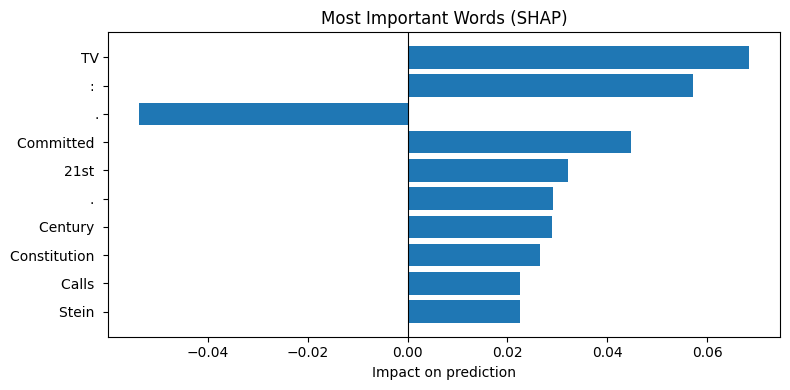

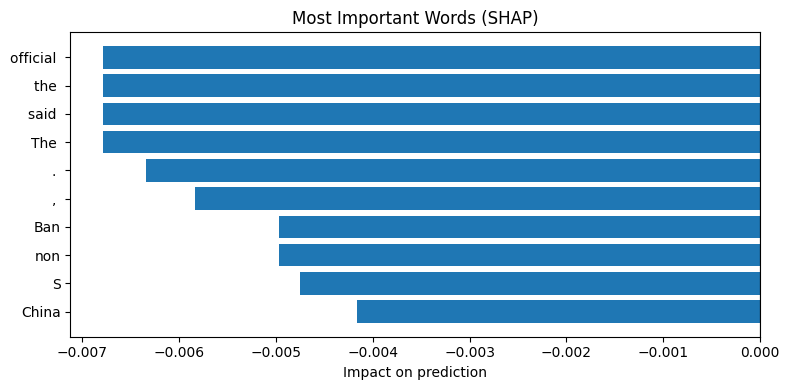

In [80]:
import matplotlib.pyplot as plt

def plot_top_words(dfs):
    for i in range(len(dfs)):
        plt.figure(figsize=(8, 4))
        plt.barh(
            dfs[i].token[::-1],
            dfs[i].importance[::-1]
        )
        plt.axvline(0, color="black", linewidth=0.8)
        plt.title("Most Important Words (SHAP)")
        plt.xlabel("Impact on prediction")
        plt.tight_layout()
        plt.show()

plot_top_words(top_words(shap_values, 2))

In [81]:
N_TEXTS = 100
texts = df_concat['text'].dropna().tolist()[:N_TEXTS]

shap_values = explainer(texts)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 5/100 [00:18<03:15,  2.06s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   8%|▊         | 8/100 [00:31<05:09,  3.36s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  97%|█████████▋| 97/100 [06:37<00:11,  3.77s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [06:50<00:00,  3.93s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [06:58,  4.27s/it]


In [89]:
import copy

N_TEXTS = 100
texts = df_concat['text'].dropna().tolist()[:N_TEXTS]
values_sorted = [np.argsort(-shap_arr[:, 0]) for shap_arr in shap_values.values]

first_prediction = predict_torch(texts)
current_prediction = copy.deepcopy(first_prediction)

current_texts = copy.deepcopy(texts)
new_texts = copy.deepcopy(texts)

current_words = copy.deepcopy(list(shap_values.data))
new_words = copy.deepcopy(list(shap_values.data))

for candidate_num in range(50):
    for i in range(N_TEXTS):
        values = values_sorted[i]
        candidate_idx = values[candidate_num]

        new_words[i][candidate_idx] = ''

        new_text = ''.join(new_words[i])
        new_texts[i] = new_text

    new_prediction = predict_torch(new_texts)
    influence = (current_prediction - new_prediction)[:, 0]

    for i in range(N_TEXTS):
        if influence[i] > 0:
            current_texts[i] = new_texts[i]
            current_prediction[i] = new_prediction[i]
            current_words[i] = new_words[i]

    new_words = copy.deepcopy(current_words)

second_prediction = predict_torch(current_texts)
np.sum(np.argmax(first_prediction, axis = 1)), np.sum(np.argmax(second_prediction, axis = 1))

0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998142
0.9998006
0.9998006
0.9998006
0.9998006
0.9998006
0.9998006


(np.int64(1), np.int64(2))

In [98]:
import numpy as np
import copy

# --- parametry ---
N_TEXTS = 40
MAX_STEPS = 60              # max liczba prób usunięć (na tekst)
RECOMPUTE_EVERY = 5        # co ile zaakceptowanych kroków globalnie przeliczać SHAP
TARGETED = True             # jeśli True: atak do konkretnej klasy (TARGET_CLASS)
TARGET_CLASS = 1            # np. 1="real" (jeśli TARGETED=True)

# --- dane ---
texts = df_concat["text"].dropna().tolist()[:N_TEXTS]

# --- stan bieżący ---
current_texts = copy.deepcopy(texts)
current_pred  = predict_torch(current_texts)          # (N, C)
first_pred    = current_pred.copy()

# ile edycji zaakceptowano per tekst (ważne, bo SHAP będzie liczony dla aktualnego tekstu)
accepted_steps = np.zeros(N_TEXTS, dtype=int)

def join_tokens(tokens):
    # SHAP Text zwykle trzyma tokeny razem z whitespace -> ''.join jest OK
    # Jeśli u Ciebie tokeny są "gołe", zmień na: return " ".join(tokens)
    return "".join(tokens)

def pick_ranking(shap_vals_i, class_idx, mode="pos"):
    """
    shap_vals_i: (n_tokens, n_classes) albo (n_tokens,) zależnie od explainer'a
    mode:
      - "pos": największe dodatnie dla danej klasy (najbardziej wspierające)
      - "abs": największe |shap| dla danej klasy
    """
    if shap_vals_i.ndim == 1:
        v = shap_vals_i
    else:
        v = shap_vals_i[:, class_idx]

    if mode == "abs":
        return np.argsort(-np.abs(v))
    else:
        return np.argsort(-v)

def current_target_class(i):
    if TARGETED:
        return TARGET_CLASS
    return int(np.argmax(current_pred[i]))

# --- główna pętla ---
for step in range(MAX_STEPS):

    # 1) okresowo przelicz SHAP dla AKTUALNYCH tekstów
    if step % RECOMPUTE_EVERY == 0:
        shap_values = explainer(current_texts)

        # dla każdego tekstu budujemy ranking tokenów wg (aktualnej) klasy celu
        ranks = []
        for i in range(N_TEXTS):
            cls = current_target_class(i)
            ranks.append(pick_ranking(shap_values.values[i], cls, mode="pos"))

    # 2) zbuduj kandydatów: w każdym tekście usuń "następny" token wg rankingu
    new_texts = current_texts.copy()
    edited_token_idx = np.full(N_TEXTS, -1, dtype=int)

    for i in range(N_TEXTS):
        toks = list(shap_values.data[i])
        r = ranks[i]

        k = accepted_steps[i]  # usuwamy "kolejny" token względem tego, ile już zaakceptowaliśmy
        if k >= len(r):
            continue

        idx = int(r[k])
        if idx < 0 or idx >= len(toks):
            continue

        toks[idx] = tokenizer.mask_token   # usunięcie tokenu; alternatywnie: toks[idx] = tokenizer.mask_token
        new_texts[i] = join_tokens(toks)
        edited_token_idx[i] = idx

    # 3) policz predykcje po modyfikacji
    new_pred = predict_torch(new_texts)

    # 4) kryterium akceptacji (greedy):
    #    - untargeted: zmniejsz prawdopodobieństwo aktualnej klasy (albo doprowadź do flipa)
    #    - targeted: zwiększ prawdopodobieństwo TARGET_CLASS
    for i in range(N_TEXTS):
        if edited_token_idx[i] == -1:
            continue

        if TARGETED:
            cls = TARGET_CLASS
            influence = new_pred[i, cls] - current_pred[i, cls]   # chcemy wzrost
            accept = influence > 0
        else:
            cls = int(np.argmax(current_pred[i]))
            influence = current_pred[i, cls] - new_pred[i, cls]   # chcemy spadek
            accept = influence > 0

        if accept:
            current_texts[i] = new_texts[i]
            current_pred[i]  = new_pred[i]
            accepted_steps[i] += 1

    # (opcjonalnie) szybki monitoring: ile flipów już uzyskano (untargeted)
    if not TARGETED:
        flips = np.sum(np.argmax(current_pred, axis=1) != np.argmax(first_pred, axis=1))
        print(f"step={step:02d} flips={flips}/{N_TEXTS}")

second_pred = current_pred
print("Before (sum class1):", np.sum(np.argmax(first_pred, axis=1)))
print("After  (sum class1):", np.sum(np.argmax(second_pred, axis=1)))

print(shap_values.values[0][values_sorted[0]])

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  12%|█▎        | 5/40 [00:18<01:14,  2.12s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██        | 8/40 [00:31<01:48,  3.40s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  85%|████████▌ | 34/40 [02:15<00:28,  4.75s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 41it [02:46,  4.38s/it]


Before (sum class1): 1
After  (sum class1): 3
[[ 0.00873688 -0.00873688]
 [ 0.00773743 -0.00773743]
 [ 0.00692728 -0.00692728]
 ...
 [-0.00431861  0.00431861]
 [-0.00515122  0.00515122]
 [-0.00796179  0.00796179]]
